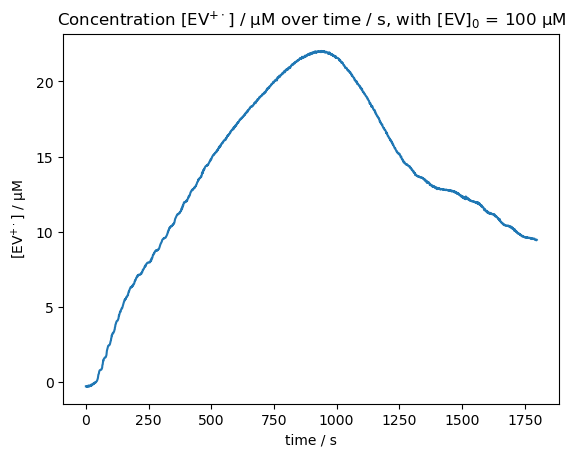

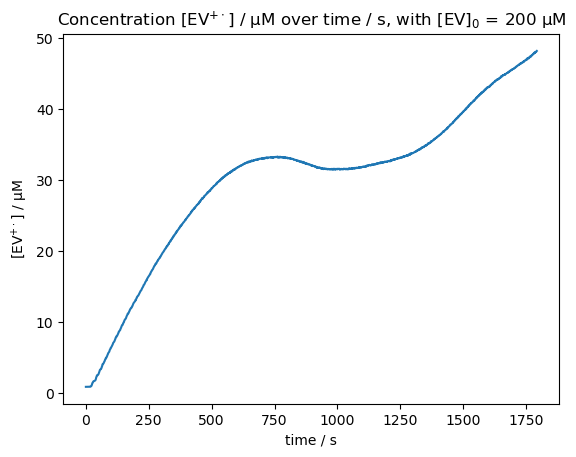

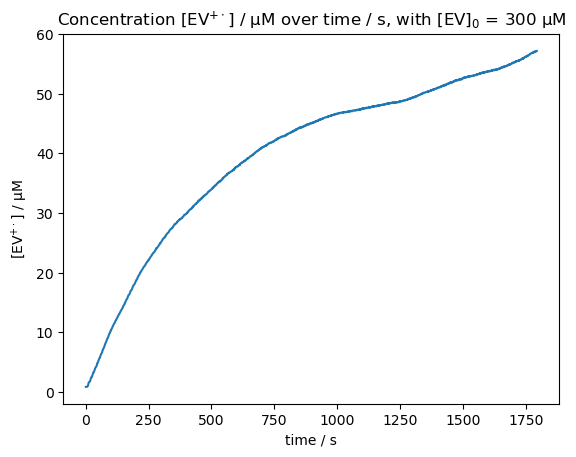

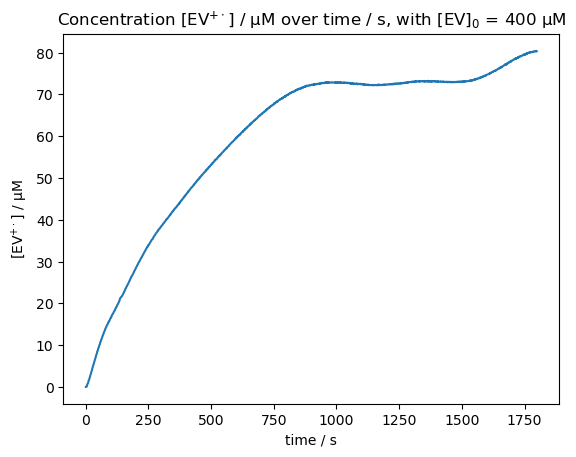

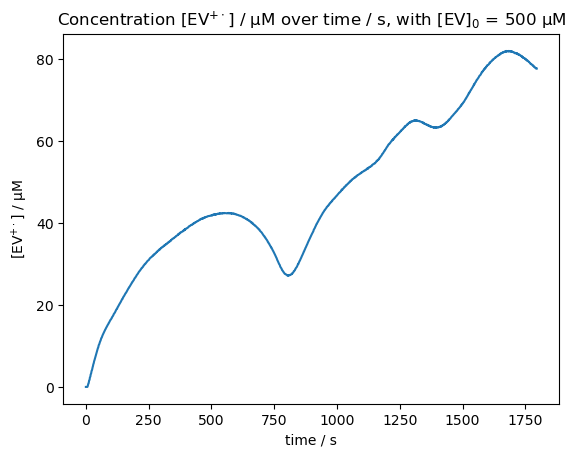

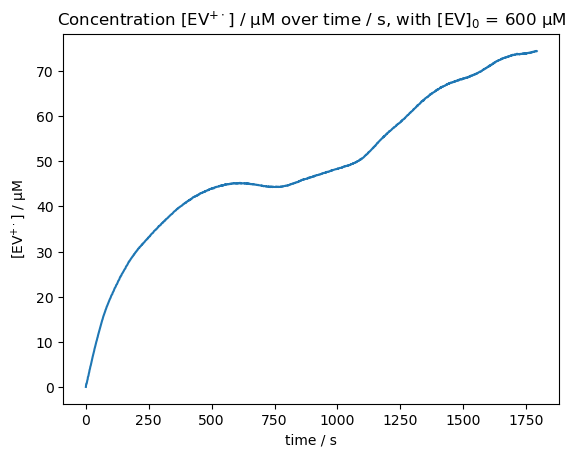

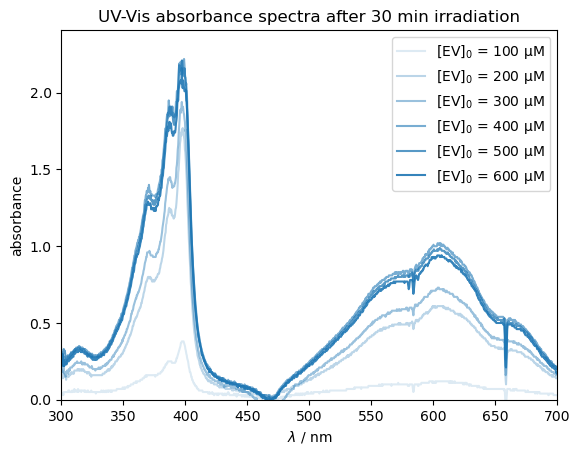

In [12]:
from matplotlib import pyplot as plt
from functions import *

# EV and Ru(bpy)3 stock solutions now made in pH 6 buffer
# mixing limitations in cuvette, colour gradient seen

# V(Ru(bpy)3, 1 mM, buffer) = 200 ul, V(EDTA, saturated, buffer) = 1 ml, made up to 3 ml pH 6 buffer
# V(EV, 1 mM, buffer) in ul used and start times for each run
runs = [(300, "12-10-37-000"),
        (600, "12-51-20-000"),
        (900, "13-35-15-000"),
        (1200, "14-10-27-000"),
        (1500, "14-45-38-000"),
        (1800, "15-19-52-000")]

# concentration vs time plot for each run
for (v, start) in runs:
    data = f'./results/260630_Rubpy_EV_EDTA_Buffered/Rubpy_EV_{v}_EDTA_Buffered'
    t, c = concvstime(data, 600, 10, 1e-2, 1.22e6, start=start, duration=30*60)
    plt.plot(t, [conc*1e6 for conc in c]) # plot time in seconds, concentrations in μM
    plt.xlabel(r'time / s')
    plt.ylabel(r'[EV$^{+\cdot}$] / μM')
    plt.title(r'Concentration [EV$^{+\cdot}$] / μM over time / s, with [EV]$_0$ = '
              f'{solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3)*1e6:.0f} μM')
    plt.show()

# plots the uv-vis absorption spectrum in the last file of each run
for (v, _) in runs:
    data = f'./results/260630_Rubpy_EV_EDTA_Buffered/Rubpy_EV_{v}_EDTA_Buffered'
    lastfile = max(Path(data).iterdir(), key=lambda p: p.name).name
    plt.plot(*uvvis(data+"/"+lastfile), color="#1F77B4", alpha=v/2000, label=r'[EV]$_0$ = '
             f'{solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3)*1e6:.0f} μM')
plt.xlim(300, 700)
plt.ylim(bottom=0)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.title('UV-Vis absorbance spectra after 30 min irradiation')
plt.legend()
plt.show()
    